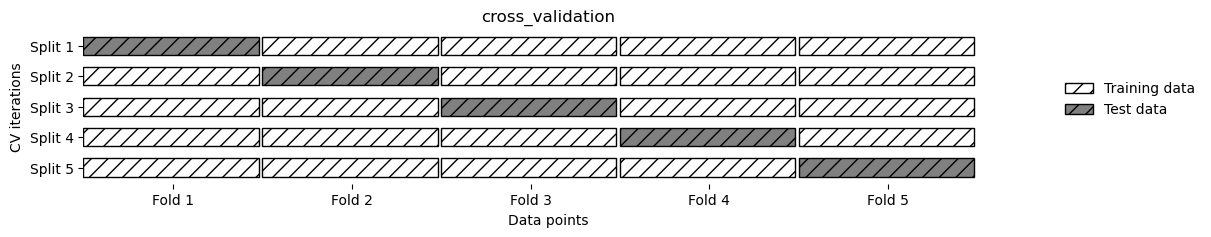

In [1]:
import mglearn
mglearn.plots.plot_cross_validation()

## k-fold cross validation (kNN)

In [2]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import numpy as np

In [3]:
iris = load_iris()
scaler = StandardScaler()
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

In [4]:
score_train = []
score_test = []

for train_idx, test_idx in kfold.split(iris.data, iris.target):
    
    X_train = iris.data[train_idx]
    y_train = iris.target[train_idx]
    X_test = iris.data[test_idx]
    y_test = iris.target[test_idx]
    
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    clf = KNeighborsClassifier(n_neighbors = 5)
    clf.fit(X_train_scaled, y_train)
    
    y_train_hat = clf.predict(X_train_scaled)
    score_train.append(accuracy_score(y_train, y_train_hat))    
    y_test_hat = clf.predict(X_test_scaled)
    score_test.append(accuracy_score(y_test, y_test_hat))

In [5]:
score_train, score_test

([0.9666666666666667, 0.9583333333333334, 0.975, 0.9583333333333334, 0.975],
 [0.9333333333333333, 1.0, 0.9333333333333333, 1.0, 0.9])

## grid search with train,val,test

#### select the best hyperparameter using the validation set

In [6]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

iris = load_iris()
X_trainval, X_test, y_trainval, y_test = train_test_split(
    iris.data, iris.target, test_size=0.25, random_state=0)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=1)

best_score = 0

for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
    for C in [0.001, 0.01, 0.1, 1, 10, 100]:

        svm = SVC(gamma=gamma, C=C)
        svm.fit(X_train, y_train)

        y_valid_hat = svm.predict(X_valid)
        score = accuracy_score(y_valid, y_valid_hat)
        
        if score > best_score:
            best_score = score
            best_parameters = {'C': C, 'gamma': gamma}

#### build a model on both training and validation data

In [7]:
svm = SVC(**best_parameters)
svm.fit(X_trainval, y_trainval)
y_test_hat = svm.predict(X_test)
test_score = accuracy_score(y_test, y_test_hat)
print("Best score on validation set: {:.2f}".format(best_score))
print("Best hyperparameters: ", best_parameters)
print("Test set score with best hyperparameters: {:.2f}".format(test_score))

Best score on validation set: 0.96
Best hyperparameters:  {'C': 10, 'gamma': 0.001}
Test set score with best hyperparameters: 0.92


## grid search with cross validation (using GridSearchCV)

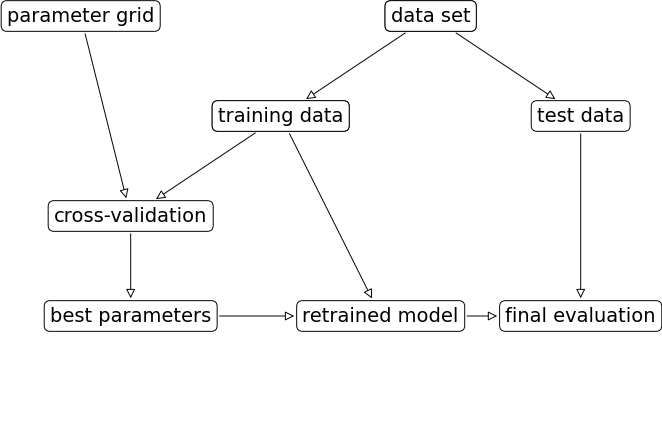

In [8]:
import mglearn
mglearn.plots.plot_grid_search_overview()

In [9]:
from sklearn.model_selection import GridSearchCV

X_trainval, X_test, y_trainval, y_test = train_test_split(
    iris.data, iris.target, test_size=0.25, random_state=0)

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=2)

In [10]:
hyperparam_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100],
               'gamma': [0.001, 0.01, 0.1, 1, 10, 100]}
grid_search = GridSearchCV(SVC(), hyperparam_grid, scoring='accuracy', refit=True, cv=kfold)
grid_search.fit(X_trainval, y_trainval)

print("Best score on validation set: {:.2f}".format(grid_search.best_score_))
print("Best hyperparameters: {}".format(grid_search.best_params_))

Best score on validation set: 0.98
Best hyperparameters: {'C': 10, 'gamma': 0.1}


In [11]:
y_test_hat = grid_search.predict(X_test)
test_score = accuracy_score(y_test, y_test_hat)
print("Test set score with best hyperparameters: {:.2f}".format(test_score))

Test set score with best hyperparameters: 0.97


#### visualize the result of cross_validation

In [12]:
import pandas as pd
# convert to Dataframe
results = pd.DataFrame(grid_search.cv_results_)

TypeError: Only length-1 arrays can be converted to Python scalars

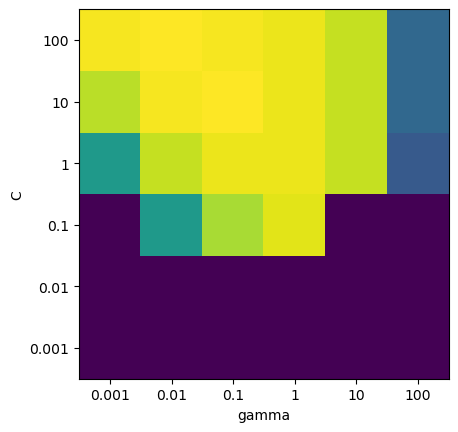

In [13]:
import matplotlib.pyplot as plt

scores = np.array(results.mean_test_score).reshape(6, 6)

# plot the mean cross-validation scores
mglearn.tools.heatmap(scores, xlabel='gamma', xticklabels=hyperparam_grid['gamma'],
                      ylabel='C', yticklabels=hyperparam_grid['C'], cmap="viridis")

#### SVC is sensitive to the setting of the hyperparameters.

#### we can also use list of dictionaries as the grid

In [14]:
hyperparam_grid = [{'kernel': ['rbf'],
               'C': [0.001, 0.01, 0.1, 1, 10, 100],
               'gamma': [0.001, 0.01, 0.1, 1, 10, 100]},
              {'kernel': ['linear'],
               'C': [0.001, 0.01, 0.1, 1, 10, 100]}]

In [15]:
grid_search = GridSearchCV(SVC(), hyperparam_grid, scoring='accuracy', refit=True, cv=kfold)
grid_search.fit(X_trainval, y_trainval)

print("Best parameters: {}".format(grid_search.best_params_))
print("Best cross-validation score: {:.2f}".format(grid_search.best_score_))

Best parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best cross-validation score: 0.98


## grid search with cross validation (without GridSearchCV)

#### how to apply scaling?

In [16]:
from sklearn.model_selection import GridSearchCV

X_trainval, X_test, y_trainval, y_test = train_test_split(
    iris.data, iris.target, test_size=0.25, random_state=0)

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=2)

In [22]:
scaler = StandardScaler()

best_score = 0
for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
    for C in [0.001, 0.01, 0.1, 1, 10, 100]:
        scores_val = []
        for train_idx, val_idx in kfold.split(X_trainval, y_trainval):
            '''TO DO'''
            X_train = X_trainval[train_idx]
            y_train = y_trainval[train_idx]
            X_valid = X_trainval[val_idx]
            y_valid = y_trainval[val_idx]

            scaler.fit(X_train)
            X_train_scaled = scaler.transform(X_train)
            X_valid_scaled = scaler.transform(X_valid)
            
            svm = SVC(gamma = gamma, C = C)
            svm.fit(X_train_scaled, y_train)

            y_valid_hat = svm.predict(X_valid_scaled)
            
            scores_val.append(accuracy_score(y_valid, y_valid_hat))
        
        mean_score = np.mean(scores_val)
        
        if mean_score > best_score:
            best_score = mean_score
            best_parameters = {'C': C, 'gamma': gamma}

print("Best score on validation set: {:.2f}".format(best_score))
print("Best hyperparameters: {}".format(best_parameters))

Best score on validation set: 0.97
Best hyperparameters: {'C': 100, 'gamma': 0.01}


In [ ]:
'''TO DO'''



svm = SVC(**best_parameters)
svm.fit(X_trainval_scaled, y_trainval)

y_test_hat = svm.predict(X_test_scaled)

test_score = accuracy_score(y_test, y_test_hat)
print("Test set score with best hyperparameters: {:.2f}".format(test_score))

nested StratifiedKFold